# 01 - Exploratory Data Analysis

Student Depression Dataset — environment check and data load.

In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print('Python executable:', sys.executable)
print('Python version:', sys.version)
print('pandas', pd.__version__, '| numpy', np.__version__)

Python executable: C:\Users\Acer\Documents\Mental-health-prediction\.venv\Scripts\python.exe
Python version: 3.12.6 (tags/v3.12.6:a4a2d2b, Sep  6 2024, 20:11:23) [MSC v.1940 64 bit (AMD64)]
pandas 3.0.5 | numpy 2.5.2


In [2]:
DATA_PATH = '../data/raw/Student Depression Dataset.csv'

df = pd.read_csv(DATA_PATH)
print('Shape:', df.shape)
df.head()

Shape: (27901, 18)


,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0


In [3]:
df.describe()

,id,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Work/Study Hours,Financial Stress,Depression
count,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27898.000000,27901.000000
mean,70442.149421,25.822300,3.141214,0.000430,7.656104,2.943837,0.000681,7.156984,3.139867,0.585499
std,40641.175216,4.905687,1.381465,0.043992,1.470707,1.361148,0.044394,3.707642,1.437347,0.492645
min,2.000000,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,35039.000000,21.000000,2.000000,0.000000,6.290000,2.000000,0.000000,4.000000,2.000000,0.000000
50%,70684.000000,25.000000,3.000000,0.000000,7.770000,3.000000,0.000000,8.000000,3.000000,1.000000
75%,105818.000000,30.000000,4.000000,0.000000,8.920000,4.000000,0.000000,10.000000,4.000000,1.000000
max,140699.000000,59.000000,5.000000,5.000000,10.000000,5.000000,4.000000,12.000000,5.000000,1.000000


In [4]:
missing= df.isnull().sum().sort_values(ascending=False)
missing[missing > 0]

Financial Stress    3
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

## Structural overview

Shape, dtypes, and duplicate rows — facts only, no decisions yet.

In [6]:
df.info()
print('\nDuplicate rows:', df.duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     27901 non-null  int64  
 1   Gender                                 27901 non-null  str    
 2   Age                                    27901 non-null  float64
 3   City                                   27901 non-null  str    
 4   Profession                             27901 non-null  str    
 5   Academic Pressure                      27901 non-null  float64
 6   Work Pressure                          27901 non-null  float64
 7   CGPA                                   27901 non-null  float64
 8   Study Satisfaction                     27901 non-null  float64
 9   Job Satisfaction                       27901 non-null  float64
 10  Sleep Duration                         27901 non-null  str    
 11  Dietary Habit


Duplicate rows: 0


## Missing values

Count and percentage of missing values per column.

In [7]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct}).sort_values('missing_count', ascending=False)

,missing_count,missing_pct
Financial Stress,3,0.01
id,0,0.00
Gender,0,0.00
Age,0,0.00
Profession,0,0.00
City,0,0.00
Work Pressure,0,0.00
CGPA,0,0.00
Study Satisfaction,0,0.00
Academic Pressure,0,0.00


## Numeric summary

Descriptive statistics for numeric columns (spot outliers, ranges, scale differences).

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,27901.0,70442.149421,40641.175216,2.0,35039.00,70684.00,105818.00,140699.0
Age,27901.0,25.822300,4.905687,18.0,21.00,25.00,30.00,59.0
Academic Pressure,27901.0,3.141214,1.381465,0.0,2.00,3.00,4.00,5.0
Work Pressure,27901.0,0.000430,0.043992,0.0,0.00,0.00,0.00,5.0
CGPA,27901.0,7.656104,1.470707,0.0,6.29,7.77,8.92,10.0
Study Satisfaction,27901.0,2.943837,1.361148,0.0,2.00,3.00,4.00,5.0
Job Satisfaction,27901.0,0.000681,0.044394,0.0,0.00,0.00,0.00,4.0
Work/Study Hours,27901.0,7.156984,3.707642,0.0,4.00,8.00,10.00,12.0
Financial Stress,27898.0,3.139867,1.437347,1.0,2.00,3.00,4.00,5.0
Depression,27901.0,0.585499,0.492645,0.0,0.00,1.00,1.00,1.0


## Categorical value counts

Cardinality and category frequencies for object/categorical columns (e.g. how many distinct `City` / `Profession` / `Degree` values exist, and whether any are rare).

In [9]:
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    print(f'--- {col} ({df[col].nunique()} unique) ---')
    print(df[col].value_counts().head(10))
    print()

--- Gender (2 unique) ---
Gender
Male      15547
Female    12354
Name: count, dtype: int64

--- City (52 unique) ---
City
Kalyan         1570
Srinagar       1372
Hyderabad      1340
Vasai-Virar    1290
Lucknow        1155
Thane          1139
Ludhiana       1111
Agra           1094
Surat          1078
Kolkata        1066
Name: count, dtype: int64

--- Profession (14 unique) ---
Profession
Student             27870
Architect               8
Teacher                 6
Digital Marketer        3
Content Writer          2
Chef                    2
Doctor                  2
Pharmacist              2
Civil Engineer          1
UX/UI Designer          1
Name: count, dtype: int64

--- Sleep Duration (5 unique) ---
Sleep Duration
Less than 5 hours    8310
7-8 hours            7346
5-6 hours            6183
More than 8 hours    6044
Others                 18
Name: count, dtype: int64

--- Dietary Habits (4 unique) ---
Dietary Habits
Unhealthy    10317
Moderate      9921
Healthy       7651
Others    

C:\Users\Acer\AppData\Local\Temp\ipykernel_4256\3838125154.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns


## Target variable distribution

Class balance of `Depression`.

In [10]:
df['Depression'].value_counts(normalize=True).mul(100).round(2)

Depression
1    58.55
0    41.45
Name: proportion, dtype: float64

## Numeric distributions

Histograms for numeric columns.

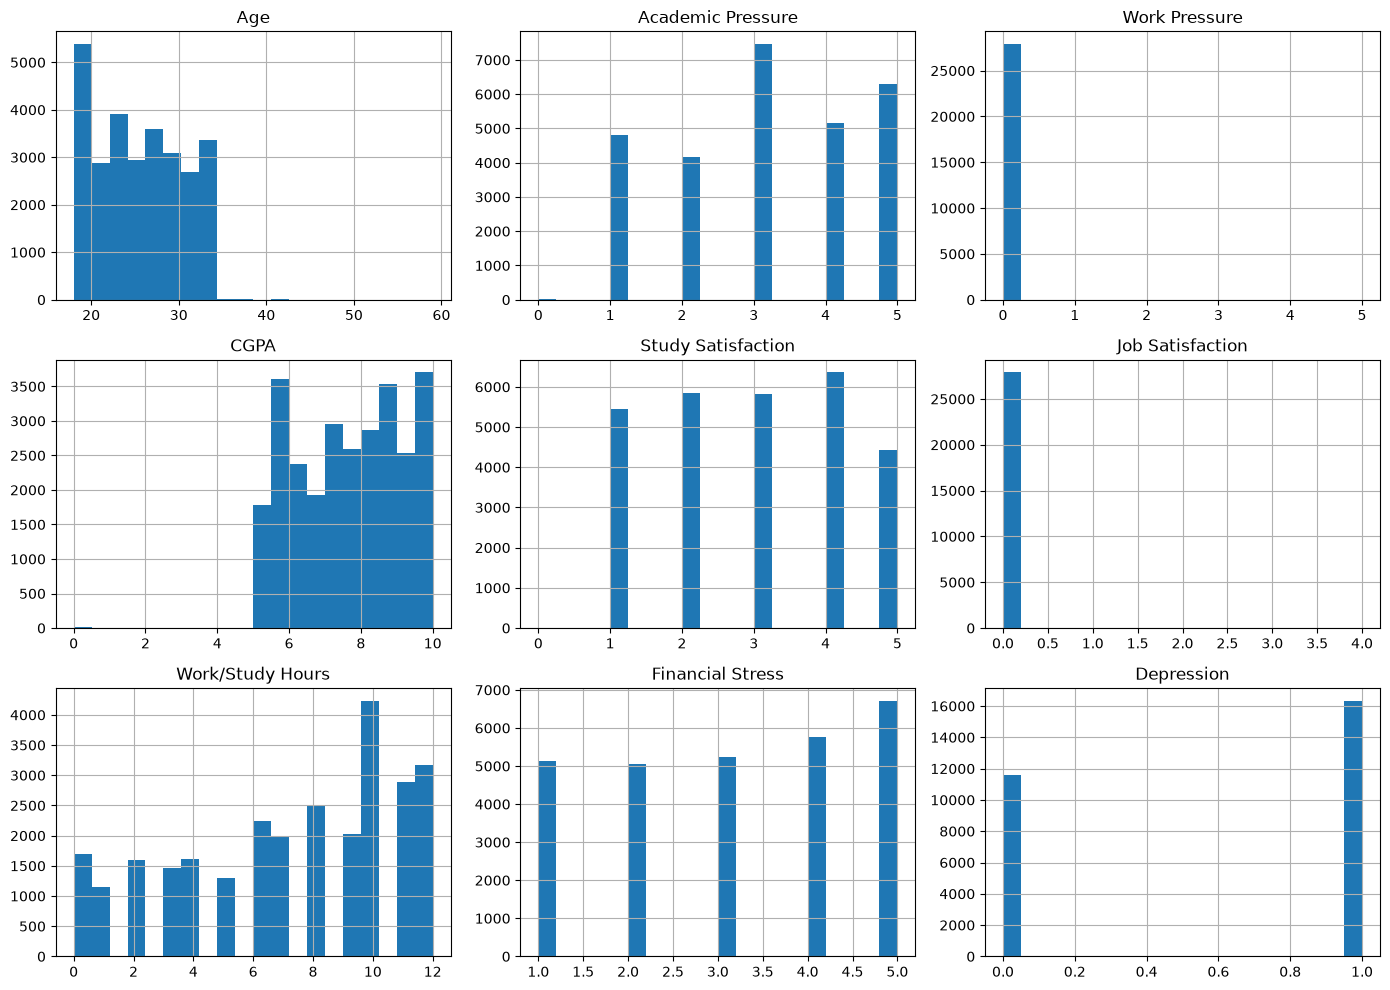

In [11]:
num_cols = df.select_dtypes(include='number').columns.drop('id', errors='ignore')
df[num_cols].hist(figsize=(14, 10), bins=20)
plt.tight_layout()
plt.show()

## Correlation heatmap

Pairwise correlation among numeric columns (including target).

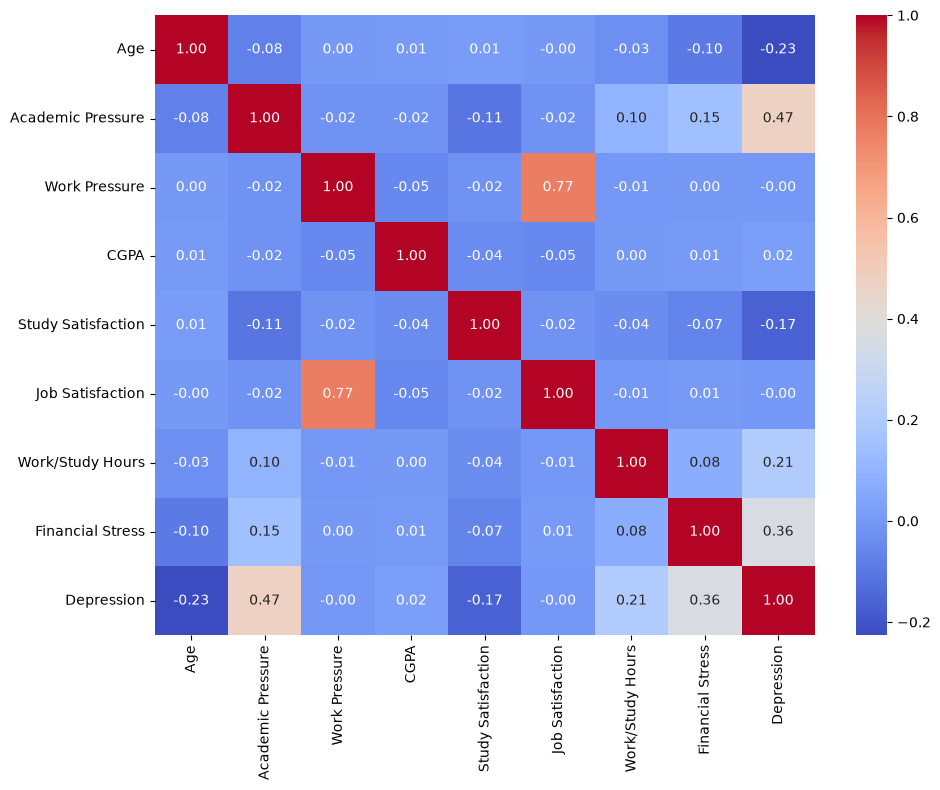

In [12]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.tight_layout()
plt.show()

## Handling missing values

Only `Financial Stress` has missing values: 3 rows out of 27,901 (0.011%). Inspecting these rows showed nothing unusual (mix of genders, cities, degrees, and both `Depression` classes present), so the missingness doesn't appear tied to any particular subgroup. Given the negligible size, these 3 rows are dropped rather than imputed.

In [13]:
df = df.dropna(subset=['Financial Stress']).reset_index(drop=True)
print('Shape after dropping rows with missing Financial Stress:', df.shape)
print('Remaining missing values:', df.isnull().sum().sum())

Shape after dropping rows with missing Financial Stress: (27898, 18)
Remaining missing values: 0


## `City` column decision: dropped

- 52 unique values, but ~22 of them are data-entry garbage (person names, degree codes like `M.Tech`/`M.Com`, stray values like `3.0`, `City`, `Less Delhi`), each appearing only 1-2 times.
- Among the ~30 legitimate cities (sample sizes ~460-1570 each), Depression rate ranged narrowly from ~52% to ~67%, with no clear regional clustering.
- Given the high cardinality, the data-quality problems, and the weak/inconsistent relationship with the target, `City` is dropped.

In [14]:
df = df.drop(columns=['City'])
print('Columns after dropping City:', list(df.columns))

Columns after dropping City: ['id', 'Gender', 'Age', 'Profession', 'Academic Pressure', 'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction', 'Sleep Duration', 'Dietary Habits', 'Degree', 'Have you ever had suicidal thoughts ?', 'Work/Study Hours', 'Financial Stress', 'Family History of Mental Illness', 'Depression']


## `id` column decision: dropped

`id` is a unique row identifier with no predictive meaning (one distinct value per row, unrelated to the target). Dropped.

In [15]:
df = df.drop(columns=['id'])
print('Columns after dropping id:', list(df.columns))

Columns after dropping id: ['Gender', 'Age', 'Profession', 'Academic Pressure', 'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction', 'Sleep Duration', 'Dietary Habits', 'Degree', 'Have you ever had suicidal thoughts ?', 'Work/Study Hours', 'Financial Stress', 'Family History of Mental Illness', 'Depression']


## `Have you ever had suicidal thoughts ?` vs `Depression`

Checking the relationship between this column and the target before deciding whether to keep it, and how to treat it.

In [16]:
col = 'Have you ever had suicidal thoughts ?'

print('--- Value counts ---')
print(df[col].value_counts())
print()

print('--- Depression rate by suicidal thoughts ---')
rate = df.groupby(col)['Depression'].agg(['mean', 'count'])
rate['mean'] = (rate['mean'] * 100).round(2)
print(rate)
print()

print('--- Cross-tab counts ---')
print(pd.crosstab(df[col], df['Depression']))

--- Value counts ---
Have you ever had suicidal thoughts ?
Yes    17656
No     10242
Name: count, dtype: int64

--- Depression rate by suicidal thoughts ---
                                        mean  count
Have you ever had suicidal thoughts ?              
No                                     23.22  10242
Yes                                    79.05  17656

--- Cross-tab counts ---
Depression                                0      1
Have you ever had suicidal thoughts ?             
No                                     7864   2378
Yes                                    3699  13957


## `Profession`, `Work Pressure`, `Job Satisfaction` decision: dropped

All three show near-zero variance: `Profession` is 99.9% "Student", and both `Work Pressure` and `Job Satisfaction` have mean/std ~0 across every profession group, including Students. A near-constant column can't help distinguish between classes, so all three are dropped.

In [17]:
df = df.drop(columns=['Profession', 'Work Pressure', 'Job Satisfaction'])
print('Columns after dropping Profession, Work Pressure, Job Satisfaction:', list(df.columns))

Columns after dropping Profession, Work Pressure, Job Satisfaction: ['Gender', 'Age', 'Academic Pressure', 'CGPA', 'Study Satisfaction', 'Sleep Duration', 'Dietary Habits', 'Degree', 'Have you ever had suicidal thoughts ?', 'Work/Study Hours', 'Financial Stress', 'Family History of Mental Illness', 'Depression']


## `Have you ever had suicidal thoughts ?` decision: kept, encoded

Strong relationship with the target (Depression rate 23.2% for "No" vs 79.1% for "Yes"), so this column is kept. Encoded as a binary 0/1 flag for modeling.

In [18]:
df['Have you ever had suicidal thoughts ?'] = (
    df['Have you ever had suicidal thoughts ?'].map({'Yes': 1, 'No': 0})
)
df['Have you ever had suicidal thoughts ?'].value_counts()

Have you ever had suicidal thoughts ?
1    17656
0    10242
Name: count, dtype: int64

## `CGPA == 0` and `Age > 40` outliers: left as-is

9 rows have `CGPA == 0` and 19 rows have `Age > 40`, out of 27,901 total rows (well under 0.1% each). Both are small enough that they won't meaningfully influence model training, so no rows are dropped or values altered.